# CAREMatch AI
## AI-Powered Healthcare Navigation and Provider Recommendation

### ML for Social Good Challenge — CIA 3

**Mission Domain:** Health

CAREMatch AI is an explainable machine learning system designed to
assist users in navigating healthcare by predicting a likely disease
or health condition from reported symptoms and recommending suitable
medical specialists, doctors, and hospitals.

The system uses an ensemble machine learning approach for disease
prediction and a separate recommendation layer for doctors and hospitals.

### Responsible Use

CAREMatch AI is a healthcare-navigation prototype. It does not provide
a medical diagnosis and does not replace consultation with a qualified
healthcare professional.

## 1. Problem Definition

People may experience symptoms without knowing which medical specialty
they should consult or which healthcare providers are suitable for their
needs.

CAREMatch AI addresses this healthcare-navigation problem through an
end-to-end machine learning system.

The system first predicts a disease or health-condition category from
user-provided information such as symptoms, age, gender, and symptom count.
The predicted condition is then mapped to an appropriate medical specialty.

Two independent recommendation paths are subsequently provided:

1. Doctor Recommendation
   - Specialty
   - Experience
   - Rating
   - Consultation fee
   - Location

2. Hospital Recommendation
   - Rating
   - Number of reviews
   - Hospital type
   - Location
   - Other available hospital information

The recommended doctor and hospital do not need to belong to the same
institution.

### Prediction Target

The primary machine learning task is:

Symptoms + Patient Information → Disease

The disease prediction is then used for healthcare-specialty navigation.

In [16]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [17]:
# Load the final disease prediction dataset
df = pd.read_csv("Healthcare.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset Shape: (25000, 6)


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscle pain",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [18]:
print("Number of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of samples: 25000
Number of columns: 6

Column Names:
['Patient_ID', 'Age', 'Gender', 'Symptoms', 'Symptom_Count', 'Disease']

Data Types:
Patient_ID        int64
Age               int64
Gender           object
Symptoms         object
Symptom_Count     int64
Disease          object
dtype: object


In [19]:
print("First five records:")
display(df.head())

First five records:


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscle pain",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [20]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     25000 non-null  int64 
 1   Age            25000 non-null  int64 
 2   Gender         25000 non-null  object
 3   Symptoms       25000 non-null  object
 4   Symptom_Count  25000 non-null  int64 
 5   Disease        25000 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.1+ MB


In [21]:
print("Missing Values:")
missing_values = df.isnull().sum()

display(
    missing_values.to_frame(name="Missing Count")
)

Missing Values:


,Missing Count
Patient_ID,0
Age,0
Gender,0
Symptoms,0
Symptom_Count,0
Disease,0


In [22]:
duplicate_count = df.duplicated().sum()

print("Exact Duplicate Rows:", duplicate_count)

Exact Duplicate Rows: 0


In [23]:
print("Unique Values Per Column:")

unique_counts = df.nunique()

display(
    unique_counts.to_frame(name="Unique Values")
)

Unique Values Per Column:


,Unique Values
Patient_ID,25000
Age,90
Gender,3
Symptoms,24359
Symptom_Count,5
Disease,30


In [26]:
# Target variable analysis
print("Number of Disease Classes:", df["Disease"].nunique())

print("\nDisease Classes:")
print(sorted(df["Disease"].unique()))

Number of Disease Classes: 30

Disease Classes:
['Allergy', 'Anemia', 'Anxiety', 'Arthritis', 'Asthma', 'Bronchitis', 'COVID-19', 'Chronic Kidney Disease', 'Common Cold', 'Dementia', 'Depression', 'Dermatitis', 'Diabetes', 'Epilepsy', 'Food Poisoning', 'Gastritis', 'Heart Disease', 'Hypertension', 'IBS', 'Influenza', 'Liver Disease', 'Migraine', 'Obesity', "Parkinson's", 'Pneumonia', 'Sinusitis', 'Stroke', 'Thyroid Disorder', 'Tuberculosis', 'Ulcer']


In [27]:
# Diesease distribution
disease_distribution = df["Disease"].value_counts()

print("Disease Distribution:")
display(disease_distribution)

Disease Distribution:


Disease
Anxiety                   911
Arthritis                 896
Food Poisoning            871
Depression                859
Allergy                   858
Bronchitis                856
Dermatitis                856
Thyroid Disorder          855
Migraine                  854
Diabetes                  850
COVID-19                  839
Ulcer                     833
Hypertension              833
Epilepsy                  832
Pneumonia                 830
Liver Disease             830
IBS                       830
Parkinson's               826
Influenza                 824
Dementia                  823
Obesity                   819
Anemia                    814
Tuberculosis              814
Chronic Kidney Disease    807
Common Cold               805
Gastritis                 804
Heart Disease             804
Sinusitis                 795
Stroke                    790
Asthma                    782
Name: count, dtype: int64

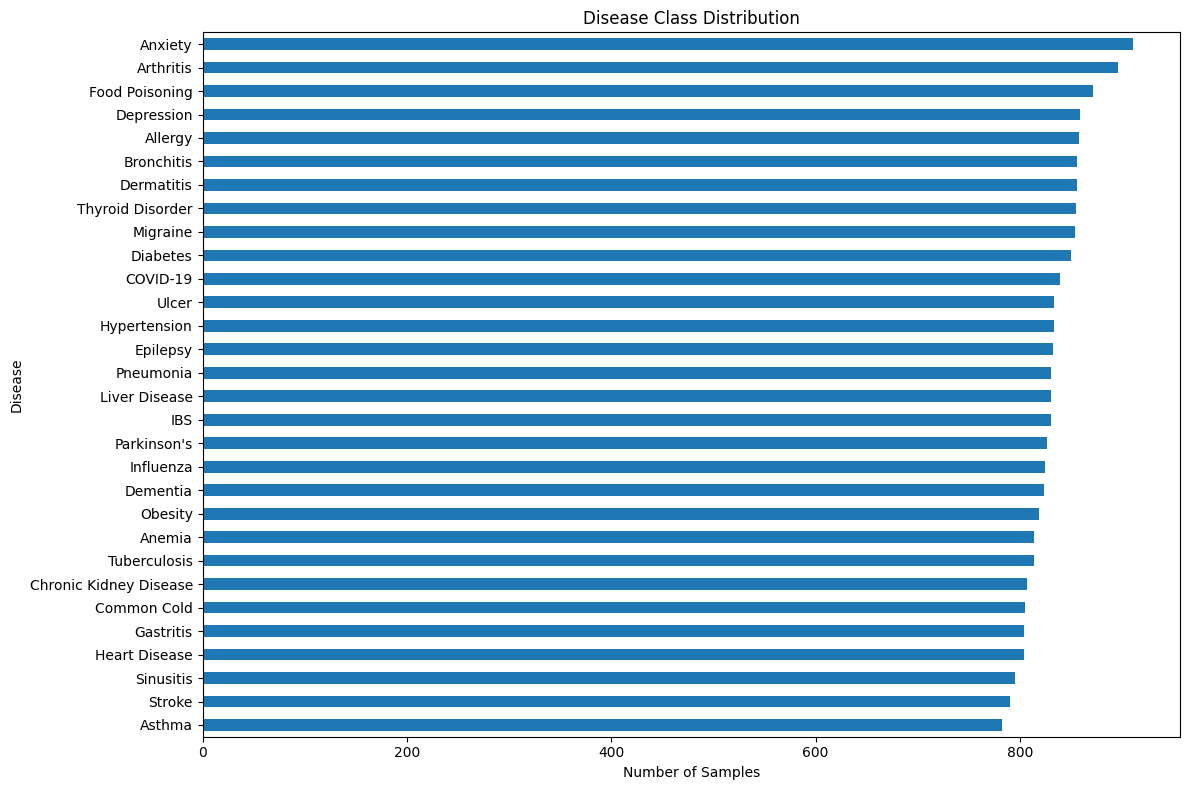

In [28]:
plt.figure(figsize=(12, 8))

disease_distribution.sort_values().plot(kind="barh")

plt.title("Disease Class Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

In [29]:
minimum_class = disease_distribution.min()
maximum_class = disease_distribution.max()

print("Minimum class count:", minimum_class)
print("Maximum class count:", maximum_class)

imbalance_ratio = maximum_class / minimum_class

print("Maximum / Minimum class ratio:",
      round(imbalance_ratio, 3))

if imbalance_ratio < 1.5:
    print("\nObservation: The dataset is reasonably balanced.")
else:
    print("\nObservation: The dataset shows noticeable class imbalance.")

Minimum class count: 782
Maximum class count: 911
Maximum / Minimum class ratio: 1.165

Observation: The dataset is reasonably balanced.


In [30]:
print("Numerical Feature Statistics:")

display(
    df[["Age", "Symptom_Count"]].describe()
)

Numerical Feature Statistics:


,Age,Symptom_Count
count,25000.000000,25000.000000
mean,45.302240,5.001440
std,26.106224,1.415796
min,1.000000,3.000000
25%,23.000000,4.000000
50%,45.000000,5.000000
75%,68.000000,6.000000
max,90.000000,7.000000


In [31]:
gender_distribution = df["Gender"].value_counts()

print("Gender Distribution:")
display(gender_distribution)

Gender Distribution:


Gender
Other     8393
Female    8336
Male      8271
Name: count, dtype: int64

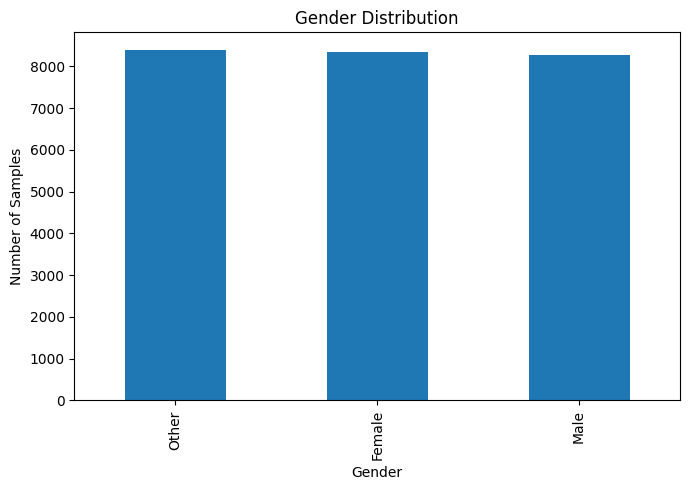

In [32]:
plt.figure(figsize=(7, 5))

gender_distribution.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

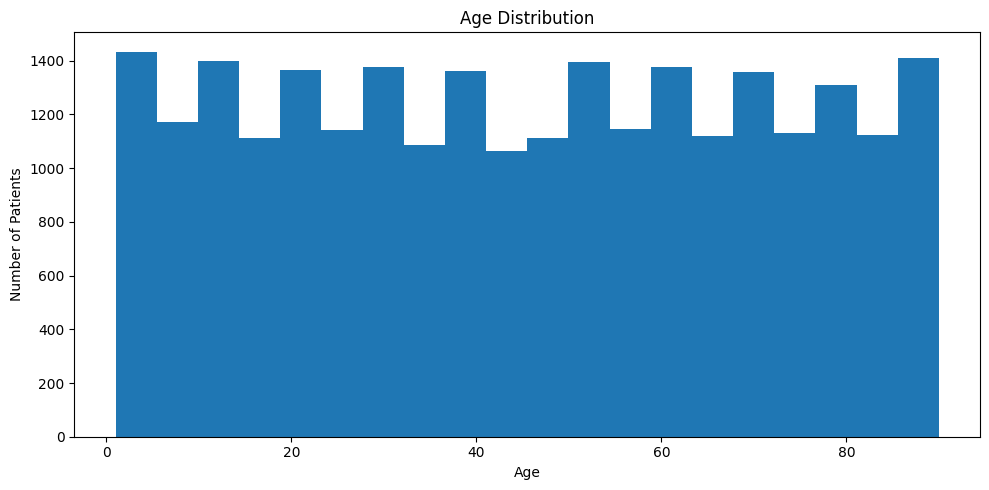

In [33]:
plt.figure(figsize=(10, 5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

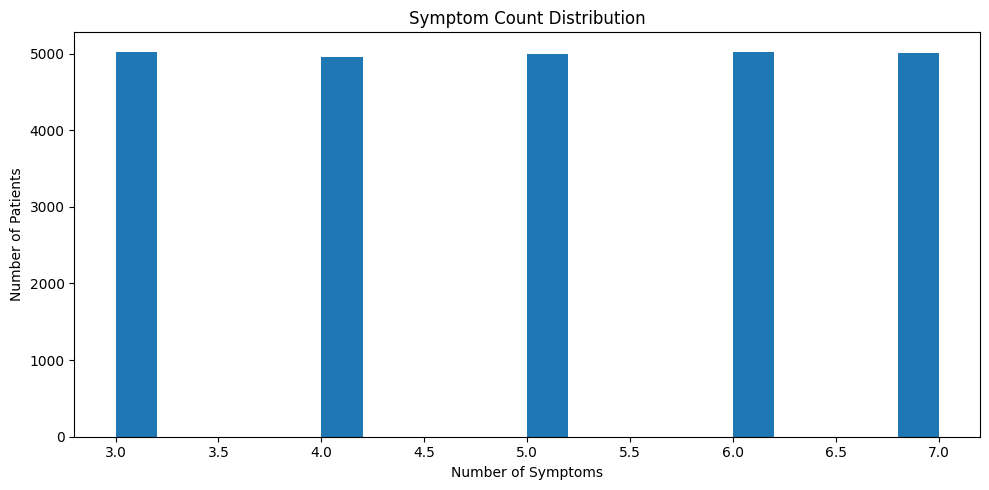

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(df["Symptom_Count"], bins=20)

plt.title("Symptom Count Distribution")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [35]:
duplicate_symptom_count = df["Symptoms"].duplicated().sum()

print("Repeated Symptom Descriptions:", duplicate_symptom_count)

Repeated Symptom Descriptions: 641


In [36]:
duplicate_symptoms = df[
    df["Symptoms"].duplicated(keep=False)
].sort_values("Symptoms")

print("Records involved in repeated symptom descriptions:",
      len(duplicate_symptoms))

display(
    duplicate_symptoms[
        ["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]
    ].head(30)
)

Records involved in repeated symptom descriptions: 1228


,Age,Gender,Symptoms,Symptom_Count,Disease
22961,86,Other,"abdominal pain, appetite loss, shortness of breath",3,Influenza
17086,89,Male,"abdominal pain, appetite loss, shortness of breath",3,Arthritis
22555,38,Male,"abdominal pain, back pain, chest pain",3,Hypertension
22863,43,Female,"abdominal pain, back pain, chest pain",3,Arthritis
8238,64,Male,"abdominal pain, back pain, cough",3,Common Cold
4209,73,Other,"abdominal pain, back pain, cough",3,Dementia
4031,37,Female,"abdominal pain, blurred vision, vomiting",3,Gastritis
22513,24,Female,"abdominal pain, blurred vision, vomiting",3,Pneumonia
200,32,Other,"abdominal pain, depression, nausea",3,Anemia
251,75,Male,"abdominal pain, depression, nausea",3,Stroke


In [37]:
symptom_disease_variation = (
    df.groupby("Symptoms")["Disease"]
    .nunique()
    .sort_values(ascending=False)
)

multiple_disease_symptoms = (
    symptom_disease_variation > 1
).sum()

print(
    "Symptom descriptions associated with multiple diseases:",
    multiple_disease_symptoms
)

display(
    symptom_disease_variation[
        symptom_disease_variation > 1
    ].head(20)
)

Symptom descriptions associated with multiple diseases: 570


Symptoms
appetite loss, weight loss, depression           4
chest pain, back pain, nausea                    4
sweating, abdominal pain, shortness of breath    4
sore throat, weight gain, swelling               3
shortness of breath, tremors, fever              3
joint pain, depression, sneezing                 3
nausea, anxiety, tremors                         3
headache, fatigue, abdominal pain                3
diarrhea, rash, blurred vision                   3
swelling, fever, weight gain                     3
diarrhea, chest pain, shortness of breath        3
runny nose, anxiety, depression                  3
fatigue, nausea, appetite loss                   3
appetite loss, muscle pain, headache             3
sneezing, appetite loss, sweating                3
chest pain, blurred vision, vomiting             3
fever, muscle pain, diarrhea                     3
sneezing, diarrhea, appetite loss                3
back pain, abdominal pain, sneezing              3
muscle pain, weight lo

In [39]:
symptom_frequency = (
    df["Symptoms"]
    .value_counts()
)

print("Most repeated symptom descriptions:")
display(symptom_frequency.head(20))

Most repeated symptom descriptions:


Symptoms
appetite loss, weight loss, depression           4
sweating, abdominal pain, shortness of breath    4
chest pain, back pain, nausea                    4
appetite loss, tremors, anxiety                  3
appetite loss, muscle pain, headache             3
chest pain, blurred vision, vomiting             3
weight loss, chest pain, depression              3
diarrhea, rash, blurred vision                   3
insomnia, cough, vomiting                        3
sore throat, weight gain, swelling               3
dizziness, back pain, depression                 3
tremors, nausea, insomnia                        3
nausea, anxiety, tremors                         3
back pain, abdominal pain, sneezing              3
sore throat, muscle pain, headache               3
runny nose, abdominal pain, blurred vision       3
muscle pain, vomiting, joint pain                3
fever, muscle pain, diarrhea                     3
sneezing, diarrhea, appetite loss                3
appetite loss, runny n

In [40]:
multi_label_summary = (
    df.groupby("Symptoms")["Disease"]
    .agg(
        unique_diseases="nunique",
        total_records="size"
    )
    .sort_values(
        ["unique_diseases", "total_records"],
        ascending=False
    )
)

print("Symptom descriptions associated with multiple diseases:")
display(
    multi_label_summary[
        multi_label_summary["unique_diseases"] > 1
    ].head(20)
)

Symptom descriptions associated with multiple diseases:


,unique_diseases,total_records
Symptoms,,
"appetite loss, weight loss, depression",4,4
"chest pain, back pain, nausea",4,4
"sweating, abdominal pain, shortness of breath",4,4
"abdominal pain, weight loss, cough",3,3
"anxiety, blurred vision, fatigue",3,3
"appetite loss, blurred vision, fatigue",3,3
"appetite loss, fatigue, rash",3,3
"appetite loss, muscle pain, headache",3,3
"appetite loss, runny nose, headache",3,3


In [41]:
example_symptom = (
    symptom_disease_variation[
        symptom_disease_variation > 1
    ].index[0]
)

print("Example symptom:", example_symptom)

display(
    df[df["Symptoms"] == example_symptom][
        ["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]
    ]
)

Example symptom: appetite loss, weight loss, depression


,Age,Gender,Symptoms,Symptom_Count,Disease
10071,42,Other,"appetite loss, weight loss, depression",3,Asthma
13008,34,Other,"appetite loss, weight loss, depression",3,Food Poisoning
21325,83,Male,"appetite loss, weight loss, depression",3,Allergy
22395,43,Male,"appetite loss, weight loss, depression",3,Dementia


## 2. Feature Selection

The dataset contains a Patient_ID column that functions as an identifier
rather than a meaningful clinical predictor. It will therefore be excluded
from model training.

The initial predictive features are:

- Age
- Gender
- Symptoms
- Symptom_Count

The target variable is:

- Disease

The usefulness of individual features will be evaluated through
model performance and feature/explainability analysis.

In [38]:
features = ["Age", "Gender", "Symptoms", "Symptom_Count"]
target = "Disease"

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['Age', 'Gender', 'Symptoms', 'Symptom_Count']

Target:
Disease


## 3. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20
split.

The training set is used to learn the patterns between patient information,
symptoms, and disease labels. The testing set is kept separate and will
only be used later to evaluate the final models on unseen data.

Stratified sampling is used to preserve the distribution of all 30 disease
classes in both the training and testing sets.

A fixed random state is used to make the experiment reproducible.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training samples: 20000
Testing samples: 5000

Training feature shape: (20000, 4)
Testing feature shape: (5000, 4)

Training target shape: (20000,)
Testing target shape: (5000,)


## 4. Verification of Class Distribution

Since this is a multi-class classification problem with 30 disease classes,
the class distribution should remain approximately consistent between the
training and testing sets.

Stratified splitting was used to ensure that each disease class is
represented proportionally in both subsets.

In [43]:
train_distribution = y_train.value_counts(normalize=True).sort_index()
test_distribution = y_test.value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    "Training (%)": train_distribution * 100,
    "Testing (%)": test_distribution * 100
})

display(comparison.round(2))

,Training (%),Testing (%)
Disease,,
Allergy,3.43,3.44
Anemia,3.26,3.26
Anxiety,3.65,3.64
Arthritis,3.58,3.58
Asthma,3.13,3.12
Bronchitis,3.42,3.42
COVID-19,3.36,3.36
Chronic Kidney Disease,3.23,3.22
Common Cold,3.22,3.22


 ## 5. Training vs Testing Class Distribution

The following visualization compares the percentage distribution of each
disease class in the training and testing datasets.

A similar distribution between the two datasets indicates that stratified
sampling has preserved the representation of the disease classes.

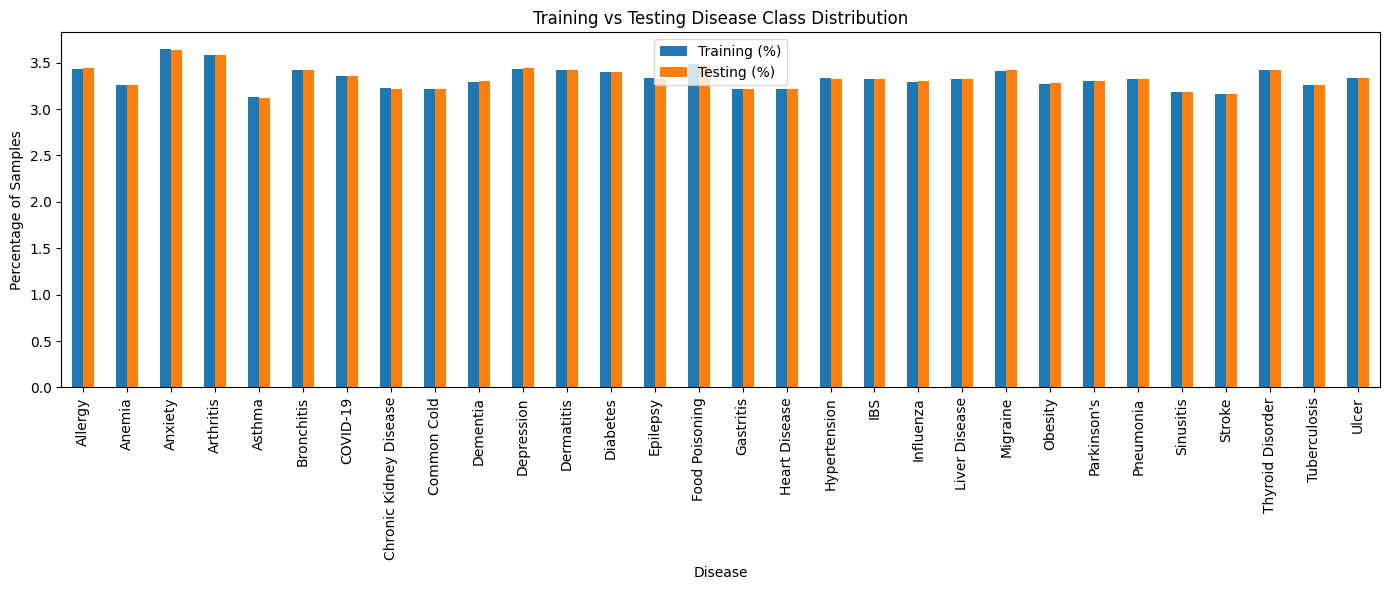

In [44]:
comparison.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Training vs Testing Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Percentage of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 6. Features Selected for Modelling

The dataset contains a Patient_ID column, but this is only an identifier
and does not contain meaningful predictive information.

Therefore, Patient_ID is excluded from model training.

The selected input features are:

- Age — numerical feature
- Gender — categorical feature
- Symptoms — text feature
- Symptom_Count — numerical feature

The target variable is Disease.

In [45]:
print("Features used for modelling:")

for feature in features:
    print("-", feature)

print("\nTarget variable:", target)

print(
    "\nPatient_ID included in model:",
    "Patient_ID" in features
)

Features used for modelling:
- Age
- Gender
- Symptoms
- Symptom_Count

Target variable: Disease

Patient_ID included in model: False


In [46]:
print("Training feature data types:")
print(X_train.dtypes)

Training feature data types:
Age               int64
Gender           object
Symptoms         object
Symptom_Count     int64
dtype: object


In [47]:
print("Symptom Count Statistics:")

display(
    X_train["Symptom_Count"].describe()
)

Symptom Count Statistics:


count    20000.000000
mean         5.001150
std          1.414408
min          3.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: Symptom_Count, dtype: float64

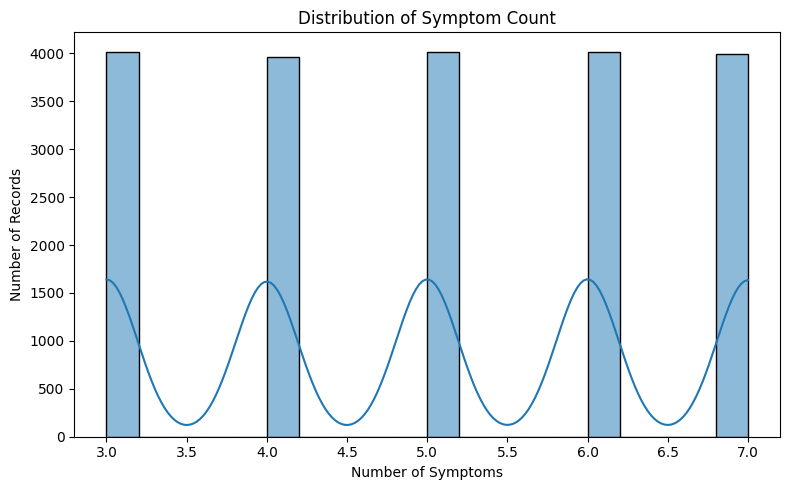

In [48]:
plt.figure(figsize=(8, 5))

sns.histplot(
    X_train["Symptom_Count"],
    bins=20,
    kde=True
)

plt.title("Distribution of Symptom Count")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 10. Leakage-Safe Preprocessing Strategy

The preprocessing operations must be learned only from the training data.

The `Symptoms` text will be converted into numerical features using
TF-IDF. `Gender` will be encoded using One-Hot Encoding, while `Age`
and `Symptom_Count` will be standardized.

A Scikit-learn `Pipeline` and `ColumnTransformer` will be used so that
the preprocessing steps are fitted only on the training data and then
applied to the unseen testing data.

This prevents information from the test set from influencing the
training process and ensures a fair evaluation of the machine learning
models.

### Preprocessing Structure

Age
   ↓
StandardScaler

Symptom_Count
   ↓
StandardScaler

Gender
   ↓
OneHotEncoder

Symptoms
   ↓
TF-IDF

       ↓
ColumnTransformer
       ↓
Combined Feature Matrix
       ↓
Machine Learning Model

## 11. Preprocessing Pipeline

The selected features contain numerical, categorical, and text data.
Therefore, different preprocessing techniques are applied to each feature
type.

### Numerical Features
- Age
- Symptom_Count

These features are standardized using StandardScaler so that their
magnitudes are comparable.

### Categorical Feature
- Gender

Gender is converted into numerical form using OneHotEncoder.

### Text Feature
- Symptoms

The symptom descriptions are converted into numerical TF-IDF features.
TF-IDF represents the importance of words based on their frequency within
the symptom descriptions.

A ColumnTransformer combines all preprocessing operations into a single
pipeline.

The preprocessing pipeline is fitted only on the training data. The test
data is transformed using the already-fitted preprocessing operations to
prevent data leakage.

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.feature_extraction.text import TfidfVectorizer

## 12. Feature Groups

The features are divided into three groups according to their data type.

- Numerical features: Age and Symptom_Count
- Categorical feature: Gender
- Text feature: Symptoms

This allows each feature type to receive an appropriate preprocessing
method.

In [50]:
numeric_features = [
    "Age",
    "Symptom_Count"
]

categorical_features = [
    "Gender"
]

text_features = [
    "Symptoms"
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Text features:", text_features)

Numerical features: ['Age', 'Symptom_Count']
Categorical features: ['Gender']
Text features: ['Symptoms']


## 13. Combined Preprocessing Transformer

A ColumnTransformer is used to apply different transformations to different
columns.

The numerical features are standardized, the categorical feature is
one-hot encoded, and the symptom text is converted into TF-IDF features.

This creates a single numerical feature representation that can be passed
to machine learning classifiers.

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "text",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                stop_words="english"
            ),
            "Symptoms"
        )
    ]
)

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


## 14. Fit Preprocessing on Training Data

The preprocessing transformer is fitted only using the training dataset.

This is an important leakage-prevention step. The testing dataset is not
used to learn the TF-IDF vocabulary, scaling parameters, or categorical
encoding.

After fitting, the same transformations are applied to both the training
and testing datasets.

In [52]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (20000, 650)
Testing processed shape: (5000, 650)


## 15. Processed Feature Matrix

After preprocessing, all input features have been converted into numerical
representations.

The resulting feature matrix combines:

- Standardized numerical features
- One-hot encoded gender categories
- TF-IDF representations of symptom descriptions

This numerical matrix can now be used by the machine learning classifiers.

In [53]:
print("Processed training data type:")
print(type(X_train_processed))

print("\nProcessed testing data type:")
print(type(X_test_processed))

print("\nTraining matrix shape:")
print(X_train_processed.shape)

print("\nTesting matrix shape:")
print(X_test_processed.shape)

Processed training data type:
<class 'scipy.sparse._csr.csr_matrix'>

Processed testing data type:
<class 'scipy.sparse._csr.csr_matrix'>

Training matrix shape:
(20000, 650)

Testing matrix shape:
(5000, 650)


In [54]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

print("\nFirst 30 processed features:")
print(feature_names[:30])

Total processed features: 650

First 30 processed features:
['numeric__Age' 'numeric__Symptom_Count' 'categorical__Gender_Female'
 'categorical__Gender_Male' 'categorical__Gender_Other' 'text__abdominal'
 'text__abdominal pain' 'text__anxiety' 'text__anxiety abdominal'
 'text__anxiety appetite' 'text__anxiety blurred' 'text__anxiety chest'
 'text__anxiety cough' 'text__anxiety depression' 'text__anxiety diarrhea'
 'text__anxiety dizziness' 'text__anxiety fatigue' 'text__anxiety fever'
 'text__anxiety headache' 'text__anxiety insomnia' 'text__anxiety joint'
 'text__anxiety muscle' 'text__anxiety nausea' 'text__anxiety pain'
 'text__anxiety rash' 'text__anxiety runny' 'text__anxiety shortness'
 'text__anxiety sneezing' 'text__anxiety sore' 'text__anxiety sweating']


## 17. Target Label Encoding

The target variable contains the names of the 30 disease classes.
LabelEncoder is used to convert these class labels into numerical
representations for model training.

The mapping is retained so that model predictions can later be converted
back into the original disease names.

The target encoder is fitted using the training target labels.

In [55]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of classes:", len(label_encoder.classes_))

print("\nDisease Label Mapping:")

for index, disease in enumerate(label_encoder.classes_):
    print(f"{index} --> {disease}")

Number of classes: 30

Disease Label Mapping:
0 --> Allergy
1 --> Anemia
2 --> Anxiety
3 --> Arthritis
4 --> Asthma
5 --> Bronchitis
6 --> COVID-19
7 --> Chronic Kidney Disease
8 --> Common Cold
9 --> Dementia
10 --> Depression
11 --> Dermatitis
12 --> Diabetes
13 --> Epilepsy
14 --> Food Poisoning
15 --> Gastritis
16 --> Heart Disease
17 --> Hypertension
18 --> IBS
19 --> Influenza
20 --> Liver Disease
21 --> Migraine
22 --> Obesity
23 --> Parkinson's
24 --> Pneumonia
25 --> Sinusitis
26 --> Stroke
27 --> Thyroid Disorder
28 --> Tuberculosis
29 --> Ulcer


In [56]:
print("First 10 original labels:")
print(y_train.iloc[:10].values)

print("\nFirst 10 encoded labels:")
print(y_train_encoded[:10])

First 10 original labels:
["Parkinson's" 'Common Cold' 'Obesity' 'Depression' 'Ulcer' 'Depression'
 'Obesity' 'Chronic Kidney Disease' 'Common Cold' 'Depression']

First 10 encoded labels:
[23  8 22 10 29 10 22  7  8 10]


## 18. Preprocessing Validation

Before training the machine learning models, we verify that:

1. The training and testing datasets remain separate.
2. The preprocessing transformer was fitted only on training data.
3. Patient_ID is not included as a predictive feature.
4. Numerical, categorical, and text features have been transformed
   appropriately.
5. The target variable has been encoded separately from the input
   features.

The processed data is now ready for model development.

In [57]:
print("Final preprocessing checks")
print("- Training samples:", X_train_processed.shape[0])
print("- Testing samples:", X_test_processed.shape[0])
print("- Number of disease classes:", len(label_encoder.classes_))
print("- Patient_ID used:", "Patient_ID" in features)
print("- Preprocessing completed: Yes")

Final preprocessing checks
- Training samples: 20000
- Testing samples: 5000
- Number of disease classes: 30
- Patient_ID used: False
- Preprocessing completed: Yes


## 19. Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classifier for the disease
prediction task.

Although Logistic Regression is not an ensemble method, it provides a
simple and interpretable benchmark against which the more advanced
ensemble models can be compared.

The model is trained using the preprocessed training data and evaluated
on the same untouched testing dataset that will be used for all subsequent
models.

The following metrics will be recorded:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The baseline results will later be compared with the Bagging, Boosting,
and Stacking/Voting ensemble models.

In [58]:
from sklearn.linear_model import LogisticRegression

# Create baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Train the model
baseline_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [59]:
# Generate predictions
y_pred_baseline = baseline_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_baseline))

Predictions generated successfully.
Number of predictions: 5000


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test_encoded,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

print("Baseline Logistic Regression Results")
print("-" * 45)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Baseline Logistic Regression Results
---------------------------------------------
Accuracy : 0.0330
Precision: 0.0335
Recall   : 0.0330
F1-Score : 0.0328


In [61]:
from sklearn.metrics import classification_report

print("Baseline Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_baseline,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Baseline Classification Report:

                        precision    recall  f1-score   support

               Allergy       0.03      0.03      0.03       172
                Anemia       0.04      0.04      0.04       163
               Anxiety       0.02      0.03      0.02       182
             Arthritis       0.04      0.06      0.05       179
                Asthma       0.03      0.02      0.02       156
            Bronchitis       0.06      0.05      0.05       171
              COVID-19       0.02      0.02      0.02       168
Chronic Kidney Disease       0.03      0.02      0.03       161
           Common Cold       0.03      0.03      0.03       161
              Dementia       0.03      0.02      0.03       165
            Depression       0.04      0.04      0.04       172
            Dermatitis       0.01      0.01      0.01       171
              Diabetes       0.01      0.01      0.01       170
              Epilepsy       0.03      0.03      0.03       166
      

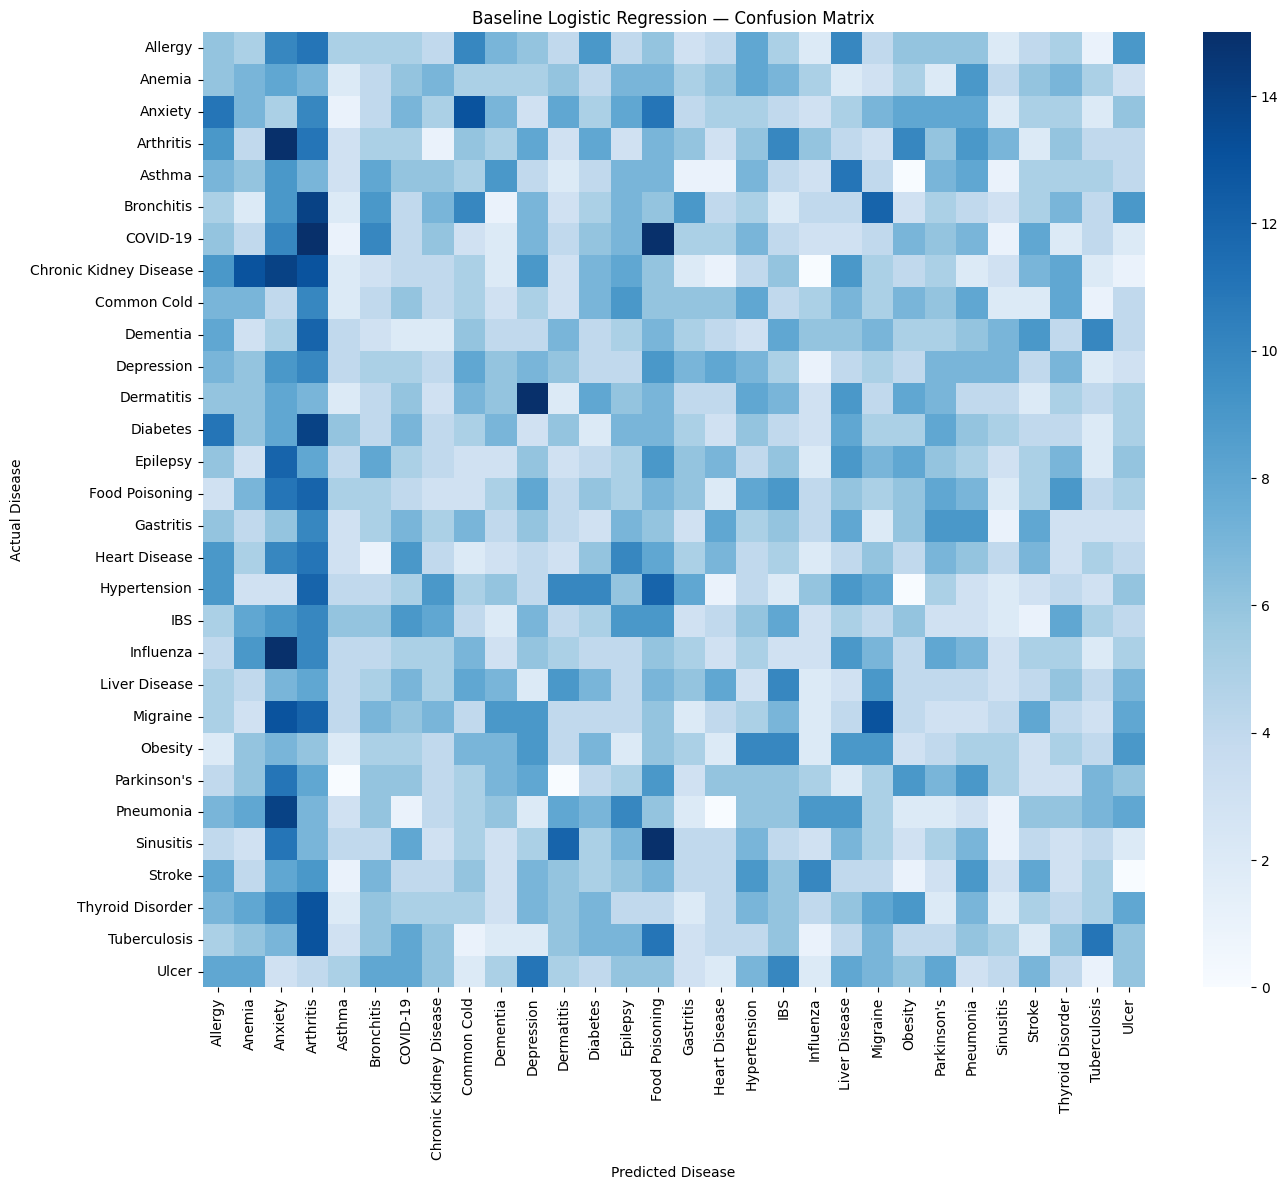

In [62]:
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(
    y_test_encoded,
    y_pred_baseline
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_baseline,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Baseline Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [63]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.033, 'Precision': 0.033453894967408304, 'Recall': 0.033, 'F1-Score': 0.032829638392123564}


### 19.7 Cross-Validation

Five-fold Stratified Cross-Validation is used to estimate how consistently
the baseline model performs across different subsets of the training data.

The test set remains completely untouched during cross-validation.

Stratification ensures that the distribution of the 30 disease classes
is approximately preserved across the folds.

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores_baseline = cross_val_score(
    baseline_model,
    X_train_processed,
    y_train_encoded,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Baseline 5-Fold Cross-Validation F1 Scores:")
print(cv_scores_baseline)

print("\nMean CV F1-Score:",
      round(cv_scores_baseline.mean(), 4))

print("Standard Deviation:",
      round(cv_scores_baseline.std(), 4))

Baseline 5-Fold Cross-Validation F1 Scores:
[0.02701676 0.03042672 0.03519429 0.03330762 0.03203132]

Mean CV F1-Score: 0.0316
Standard Deviation: 0.0028


In [65]:
baseline_results["CV F1-Score"] = cv_scores_baseline.mean()

print("Updated Baseline Results:")
print(baseline_results)

Updated Baseline Results:
{'Model': 'Logistic Regression', 'Accuracy': 0.033, 'Precision': 0.033453894967408304, 'Recall': 0.033, 'F1-Score': 0.032829638392123564, 'CV F1-Score': np.float64(0.03159534221609041)}


## 20. Bagging Ensemble — Random Forest

Random Forest is used as the bagging ensemble model.

Random Forest builds multiple decision trees using different bootstrap
samples of the training data and combines their predictions to produce
the final classification.

Compared with the Logistic Regression baseline, Random Forest can model
more complex and non-linear relationships between the patient features
and disease classes.

The Random Forest model will be evaluated using the same untouched test
set and the same metrics used for the baseline model.

Five-fold Stratified Cross-Validation will also be used on the training
data to obtain a more reliable estimate of model performance.

In [66]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [67]:
# Train Random Forest
rf_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [68]:
# Generate Random Forest predictions
y_pred_rf = rf_model.predict(
    X_test_processed
)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully.
Number of predictions: 5000


In [69]:
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf
)

rf_precision = precision_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("-" * 45)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Results
---------------------------------------------
Accuracy : 0.0322
Precision: 0.0320
Recall   : 0.0322
F1-Score : 0.0319


In [70]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report:

                        precision    recall  f1-score   support

               Allergy       0.04      0.05      0.04       172
                Anemia       0.02      0.02      0.02       163
               Anxiety       0.02      0.02      0.02       182
             Arthritis       0.03      0.04      0.04       179
                Asthma       0.02      0.02      0.02       156
            Bronchitis       0.06      0.08      0.07       171
              COVID-19       0.04      0.04      0.04       168
Chronic Kidney Disease       0.03      0.03      0.03       161
           Common Cold       0.03      0.02      0.03       161
              Dementia       0.03      0.03      0.03       165
            Depression       0.04      0.04      0.04       172
            Dermatitis       0.05      0.05      0.05       171
              Diabetes       0.06      0.07      0.06       170
              Epilepsy       0.03      0.03      0.03       166
 

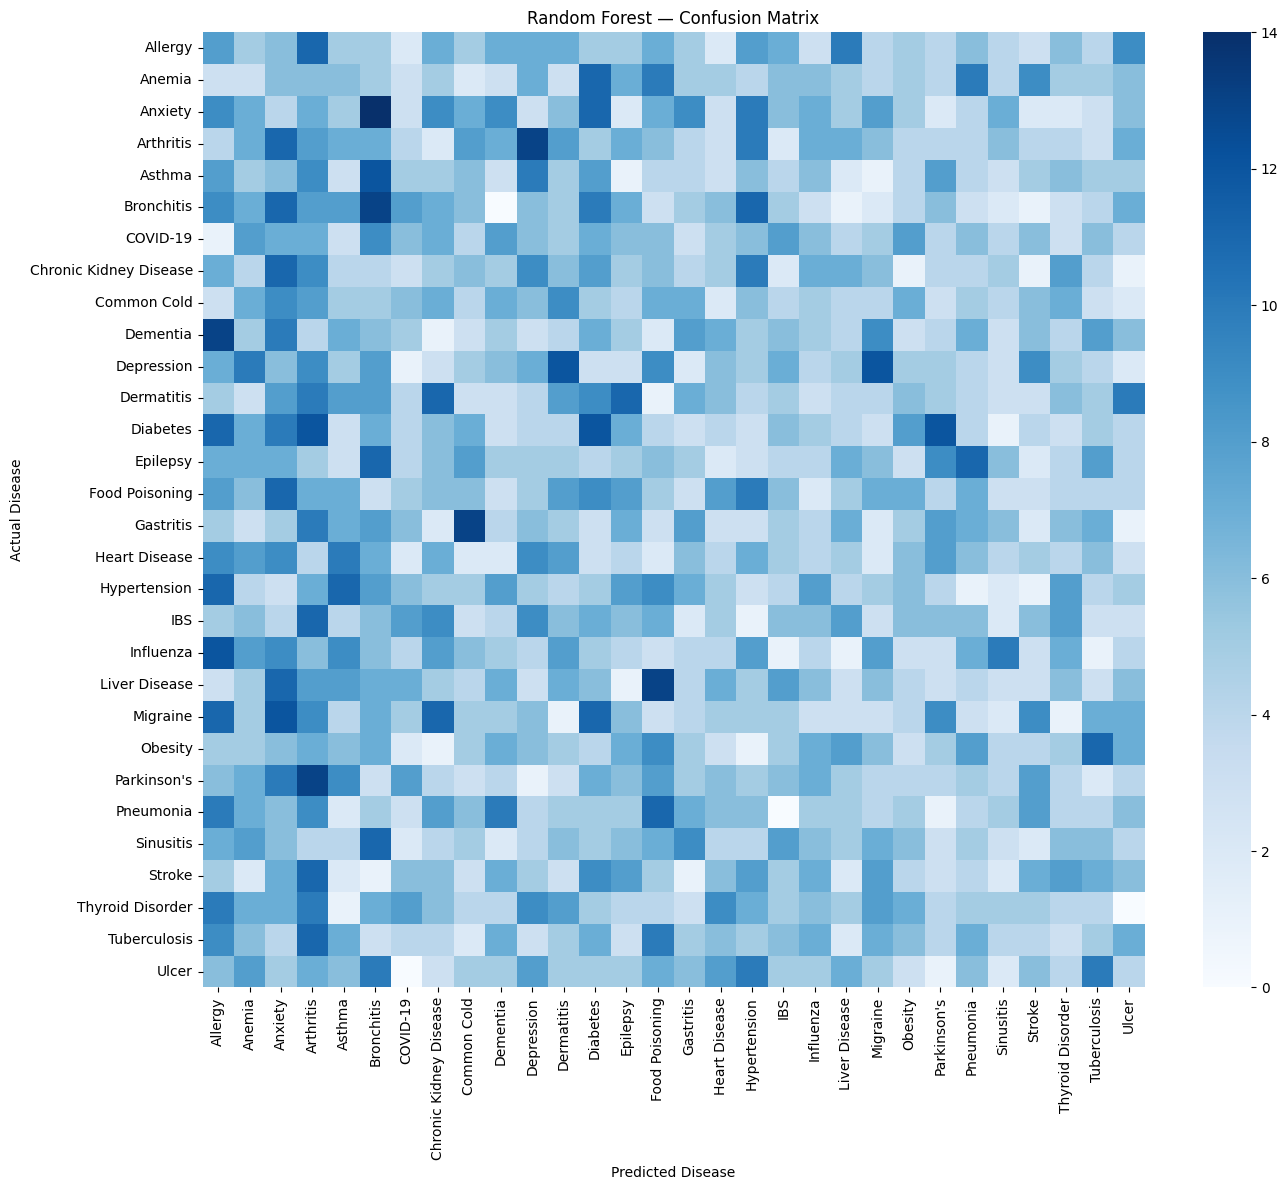

In [71]:
cm_rf = confusion_matrix(
    y_test_encoded,
    y_pred_rf
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_rf,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [72]:
cv_scores_rf = cross_val_score(
    rf_model,
    X_train_processed,
    y_train_encoded,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Random Forest 5-Fold Cross-Validation F1 Scores:")
print(cv_scores_rf)

print("\nMean CV F1-Score:",
      round(cv_scores_rf.mean(), 4))

print("Standard Deviation:",
      round(cv_scores_rf.std(), 4))

Random Forest 5-Fold Cross-Validation F1 Scores:
[0.03248306 0.03636734 0.03158791 0.03350354 0.03141881]

Mean CV F1-Score: 0.0331
Standard Deviation: 0.0018


In [73]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "CV F1-Score": cv_scores_rf.mean()
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.0322, 'Precision': 0.03195586735330347, 'Recall': 0.0322, 'F1-Score': 0.03189500012491823, 'CV F1-Score': np.float64(0.03307213172112379)}


In [74]:
comparison_results = pd.DataFrame([
    baseline_results,
    rf_results
])

display(
    comparison_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,CV F1-Score
0,Logistic Regression,0.0330,0.0335,0.0330,0.0328,0.0316
1,Random Forest,0.0322,0.0320,0.0322,0.0319,0.0331


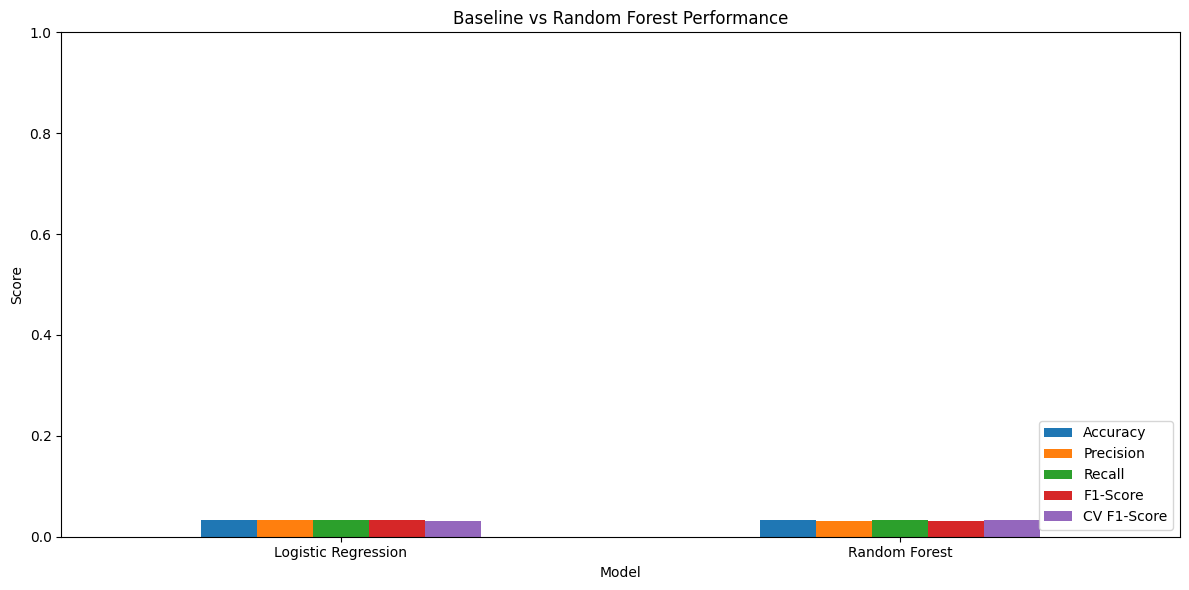

In [75]:
metrics_to_compare = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "CV F1-Score"
]

comparison_results.set_index("Model")[metrics_to_compare].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline vs Random Forest Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [76]:
print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

print("\nNumber of processed features:",
      X_train_processed.shape[1])

print("\nFeature names:")
print(feature_names[:30])

Training processed shape: (20000, 650)
Testing processed shape: (5000, 650)

Number of processed features: 650

Feature names:
['numeric__Age' 'numeric__Symptom_Count' 'categorical__Gender_Female'
 'categorical__Gender_Male' 'categorical__Gender_Other' 'text__abdominal'
 'text__abdominal pain' 'text__anxiety' 'text__anxiety abdominal'
 'text__anxiety appetite' 'text__anxiety blurred' 'text__anxiety chest'
 'text__anxiety cough' 'text__anxiety depression' 'text__anxiety diarrhea'
 'text__anxiety dizziness' 'text__anxiety fatigue' 'text__anxiety fever'
 'text__anxiety headache' 'text__anxiety insomnia' 'text__anxiety joint'
 'text__anxiety muscle' 'text__anxiety nausea' 'text__anxiety pain'
 'text__anxiety rash' 'text__anxiety runny' 'text__anxiety shortness'
 'text__anxiety sneezing' 'text__anxiety sore' 'text__anxiety sweating']


In [77]:
tfidf_transformer = preprocessor.named_transformers_["text"]

print("Number of TF-IDF features:",
      len(tfidf_transformer.get_feature_names_out()))

print("\nFirst 50 TF-IDF features:")

print(
    tfidf_transformer.get_feature_names_out()[:50]
)

Number of TF-IDF features: 645

First 50 TF-IDF features:
['abdominal' 'abdominal pain' 'anxiety' 'anxiety abdominal'
 'anxiety appetite' 'anxiety blurred' 'anxiety chest' 'anxiety cough'
 'anxiety depression' 'anxiety diarrhea' 'anxiety dizziness'
 'anxiety fatigue' 'anxiety fever' 'anxiety headache' 'anxiety insomnia'
 'anxiety joint' 'anxiety muscle' 'anxiety nausea' 'anxiety pain'
 'anxiety rash' 'anxiety runny' 'anxiety shortness' 'anxiety sneezing'
 'anxiety sore' 'anxiety sweating' 'anxiety swelling' 'anxiety tremors'
 'anxiety vomiting' 'anxiety weight' 'appetite' 'appetite loss' 'blurred'
 'blurred vision' 'breath' 'breath abdominal' 'breath anxiety'
 'breath appetite' 'breath blurred' 'breath chest' 'breath cough'
 'breath depression' 'breath diarrhea' 'breath dizziness' 'breath fatigue'
 'breath fever' 'breath headache' 'breath insomnia' 'breath joint'
 'breath muscle' 'breath nausea']


In [78]:
print("Actual test distribution:")
display(
    pd.Series(y_test_encoded)
    .value_counts()
    .sort_index()
)

print("\nRandom Forest predicted distribution:")
display(
    pd.Series(y_pred_rf)
    .value_counts()
    .sort_index()
)

Actual test distribution:


0     172
1     163
2     182
3     179
4     156
5     171
6     168
7     161
8     161
9     165
10    172
11    171
12    170
13    166
14    174
15    161
16    161
17    166
18    166
19    165
20    166
21    171
22    164
23    165
24    166
25    159
26    158
27    171
28    163
29    167
Name: count, dtype: int64


Random Forest predicted distribution:


0     217
1     180
2     227
3     247
4     169
5     213
6     134
7     170
8     151
9     155
10    177
11    174
12    201
13    163
14    184
15    150
16    148
17    179
18    152
19    158
20    144
21    159
22    147
23    144
24    161
25    116
26    137
27    148
28    151
29    144
Name: count, dtype: int64

In [79]:
sample = X_train.iloc[[0]]

print("Original sample:")
display(sample)

sample_processed = preprocessor.transform(sample)

print("\nProcessed sample shape:")
print(sample_processed.shape)

print("\nNumber of non-zero features:",
      sample_processed.nnz if hasattr(sample_processed, "nnz")
      else np.count_nonzero(sample_processed))

Original sample:


,Age,Gender,Symptoms,Symptom_Count
6243,31,Male,"appetite loss, swelling, back pain",3



Processed sample shape:
(1, 650)

Number of non-zero features: 10


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create a separate TF-IDF vectorizer for diagnostic analysis
text_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

# Fit ONLY on training symptom text
X_train_text = text_vectorizer.fit_transform(
    X_train["Symptoms"]
)

X_test_text = text_vectorizer.transform(
    X_test["Symptoms"]
)

print("Text-only training shape:", X_train_text.shape)
print("Text-only testing shape:", X_test_text.shape)

Text-only training shape: (20000, 645)
Text-only testing shape: (5000, 645)


In [81]:
text_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

text_model.fit(
    X_train_text,
    y_train_encoded
)

y_pred_text = text_model.predict(X_test_text)

text_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_text
)

text_f1 = f1_score(
    y_test_encoded,
    y_pred_text,
    average="weighted",
    zero_division=0
)

print("Text-Only Logistic Regression")
print("-" * 40)
print(f"Accuracy : {text_accuracy:.4f}")
print(f"F1-Score : {text_f1:.4f}")

Text-Only Logistic Regression
----------------------------------------
Accuracy : 0.0340
F1-Score : 0.0338


In [82]:
diagnostic_results = pd.DataFrame([
    {
        "Model": "Text-Only Logistic Regression",
        "Accuracy": text_accuracy,
        "F1-Score": text_f1
    },
    {
        "Model": "Combined Logistic Regression",
        "Accuracy": baseline_accuracy,
        "F1-Score": baseline_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "F1-Score": rf_f1
    }
])

display(
    diagnostic_results.round(4)
)

,Model,Accuracy,F1-Score
0,Text-Only Logistic Regression,0.0340,0.0338
1,Combined Logistic Regression,0.0330,0.0328
2,Random Forest,0.0322,0.0319


In [83]:
# Predictions on the training data
y_pred_text_train = text_model.predict(X_train_text)

text_train_accuracy = accuracy_score(
    y_train_encoded,
    y_pred_text_train
)

text_train_f1 = f1_score(
    y_train_encoded,
    y_pred_text_train,
    average="weighted",
    zero_division=0
)

print("Text-Only Logistic Regression")
print("-" * 45)

print(f"Training Accuracy: {text_train_accuracy:.4f}")
print(f"Training F1-Score: {text_train_f1:.4f}")

print(f"\nTesting Accuracy : {text_accuracy:.4f}")
print(f"Testing F1-Score : {text_f1:.4f}")

Text-Only Logistic Regression
---------------------------------------------
Training Accuracy: 0.1474
Training F1-Score: 0.1463

Testing Accuracy : 0.0340
Testing F1-Score : 0.0338


In [84]:
# Create a copy for analysis
analysis_df = df.copy()

# Split symptom descriptions into individual symptoms
analysis_df["Symptom_List"] = (
    analysis_df["Symptoms"]
    .str.split(", ")
)

# Explode the symptoms
exploded_symptoms = analysis_df.explode("Symptom_List")

# Count symptoms by disease
disease_symptom_counts = pd.crosstab(
    exploded_symptoms["Disease"],
    exploded_symptoms["Symptom_List"]
)

print("Disease-Symptom Matrix Shape:")
print(disease_symptom_counts.shape)

display(disease_symptom_counts.head())

Disease-Symptom Matrix Shape:
(30, 28)


Symptom_List,abdominal pain,anxiety,appetite loss,back pain,blurred vision,chest pain,cough,depression,diarrhea,dizziness,fatigue,fever,headache,insomnia,joint pain,muscle pain,nausea,rash,runny nose,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss
Disease,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Allergy,163,166,145,156,154,158,156,146,155,151,149,164,139,137,148,167,170,154,152,147,186,149,142,158,149,151,153,146
Anemia,135,136,142,163,173,149,150,143,177,146,158,154,173,159,162,163,128,137,160,152,159,140,137,131,149,143,144,145
Anxiety,134,172,161,158,163,134,163,165,170,170,169,172,171,165,145,173,147,171,153,176,158,160,163,158,170,171,197,139
Arthritis,170,149,170,175,130,137,164,178,139,170,161,163,163,171,161,155,170,167,144,190,162,172,167,136,161,162,147,142
Asthma,139,143,146,133,143,128,149,129,134,144,140,137,148,134,157,124,119,138,156,138,142,139,133,147,140,153,123,142


In [85]:
# Show the five most frequent symptoms for each disease

for disease in label_encoder.classes_:
    
    top_symptoms = (
        disease_symptom_counts.loc[disease]
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\n{disease}")
    print(top_symptoms)


Allergy
Symptom_List
sneezing       186
nausea         170
muscle pain    167
anxiety        166
fever          164
Name: Allergy, dtype: int64

Anemia
Symptom_List
diarrhea          177
blurred vision    173
headache          173
back pain         163
muscle pain       163
Name: Anemia, dtype: int64

Anxiety
Symptom_List
weight gain            197
shortness of breath    176
muscle pain            173
anxiety                172
fever                  172
Name: Anxiety, dtype: int64

Arthritis
Symptom_List
shortness of breath    190
depression             178
back pain              175
sore throat            172
insomnia               171
Name: Arthritis, dtype: int64

Asthma
Symptom_List
joint pain    157
runny nose    156
vomiting      153
cough         149
headache      148
Name: Asthma, dtype: int64

Bronchitis
Symptom_List
sore throat    174
cough          167
sweating       167
vomiting       166
chest pain     165
Name: Bronchitis, dtype: int64

COVID-19
Symptom_List
sneezing   

In [86]:
# Total number of symptom occurrences
total_symptoms = disease_symptom_counts.sum(axis=0)

# Calculate how many diseases contain each symptom
symptom_disease_presence = (
    disease_symptom_counts > 0
).sum(axis=0)

symptom_analysis = pd.DataFrame({
    "Total Occurrences": total_symptoms,
    "Number of Diseases": symptom_disease_presence
}).sort_values(
    "Number of Diseases",
    ascending=False
)

display(symptom_analysis.head(20))

,Total Occurrences,Number of Diseases
Symptom_List,,
abdominal pain,4362,30
anxiety,4506,30
weight gain,4442,30
vomiting,4464,30
tremors,4421,30
swelling,4490,30
sweating,4456,30
sore throat,4487,30
sneezing,4562,30


In [87]:
symptom_label_stats = (
    df.groupby("Symptoms")["Disease"]
    .agg(
        total_records="size",
        unique_diseases="nunique"
    )
)

print("Total unique symptom combinations:",
      symptom_label_stats.shape[0])

print(
    "Symptom combinations associated with more than one disease:",
    (symptom_label_stats["unique_diseases"] > 1).sum()
)

print(
    "Symptom combinations associated with exactly one disease:",
    (symptom_label_stats["unique_diseases"] == 1).sum()
)

print("\nMaximum number of diseases for one symptom combination:",
      symptom_label_stats["unique_diseases"].max())

Total unique symptom combinations: 24359
Symptom combinations associated with more than one disease: 570
Symptom combinations associated with exactly one disease: 23789

Maximum number of diseases for one symptom combination: 4
